In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import cv2
from keras.layers import Flatten, Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
mask_data_train = 'Face Mask Dataset/Train'
mask_data_test = 'Face Mask Dataset/Test'
val_data_train = 'Face Mask Dataset/Validation'

In [3]:
img_width = 150
img_height = 150

In [4]:
data_train = tf.keras.utils.image_dataset_from_directory(mask_data_train,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 20815 files belonging to 2 classes.


In [5]:
data_test = tf.keras.utils.image_dataset_from_directory(mask_data_test,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 992 files belonging to 2 classes.


In [6]:
val_train = tf.keras.utils.image_dataset_from_directory(val_data_train,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 800 files belonging to 2 classes.


In [7]:
data_cat = data_train.class_names
data_cat

['WithMask', 'WithoutMask']

In [8]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

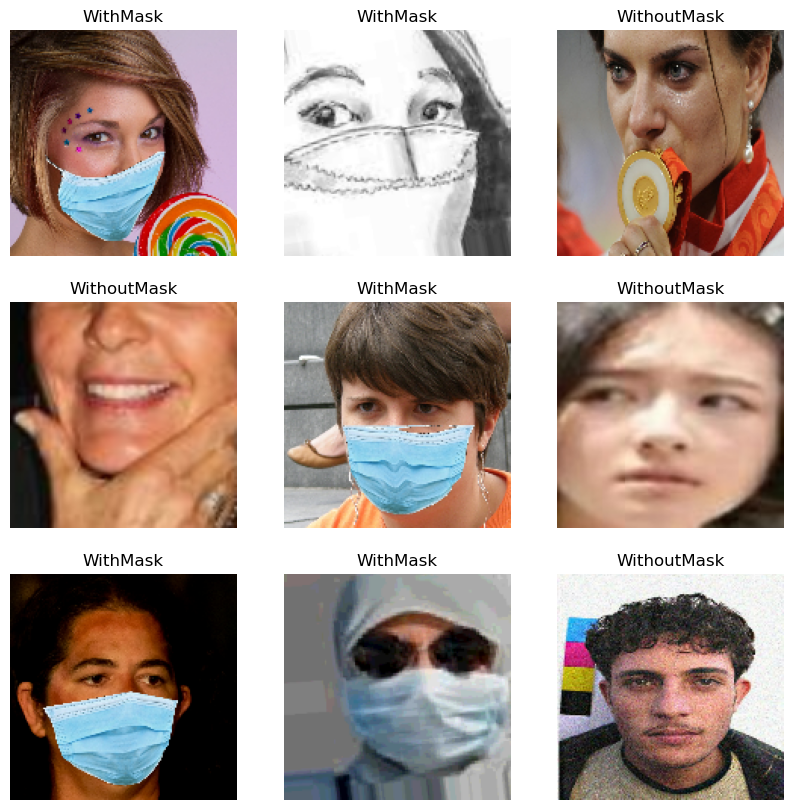

In [9]:
plt.figure(figsize=(10, 10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3, i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [10]:
CN_bas = MobileNetV3Large(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

D:\anaconda\Lib\site-packages\keras\src\applications\mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


In [11]:
CN_bas.summary()

Model: "MobileNetV3Large"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 150, 150,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 75, 75,    │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 75, 75,    │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 75, 75,    │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 75, 75,    │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 75, 75,    │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 75, 75,    │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 75, 75,    │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 77, 77,    │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 38, 38,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 38, 38,    │        256 │ expanded_conv_1_

 Total params: 2,996,352 (11.43 MB)

 Trainable params: 2,971,952 (11.34 MB)

 Non-trainable params: 24,400 (95.31 KB)

In [12]:
CN_bas.trainable = False

In [13]:
model = Sequential()
model.add(CN_bas)
model.add(GlobalAveragePooling2D())
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.4))
model.add(Dense(1, activation='sigmoid'))

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 5, 5, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,246,465 (12.38 MB)

 Trainable params: 248,193 (969.50 KB)

 Non-trainable params: 2,998,272 (11.44 MB)

In [15]:
def process(image, label):
    image =preprocess_input(image)
    return image, label
data_train = data_train.map(process)
val_train = val_train.map(process)

In [16]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), 
            loss = keras.losses.BinaryCrossentropy(), metrics = ['accuracy'])

In [17]:
epochs = 10
history = model.fit(data_train,validation_data=val_train, epochs = epochs)

Epoch 1/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 250s 370ms/step - accuracy: 0.9626 - loss: 0.4710 - val_accuracy: 0.9937 - val_loss: 0.3531
Epoch 2/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 245s 376ms/step - accuracy: 0.9846 - loss: 0.3532 - val_accuracy: 0.9975 - val_loss: 0.2933
Epoch 3/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 245s 377ms/step - accuracy: 0.9896 - loss: 0.2932 - val_accuracy: 0.9987 - val_loss: 0.2457
Epoch 4/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 242s 371ms/step - accuracy: 0.9923 - loss: 0.2441 - val_accuracy: 0.9987 - val_loss: 0.2057
Epoch 5/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 228s 351ms/step - accuracy: 0.9928 - loss: 0.2057 - val_accuracy: 0.9987 - val_loss: 0.1720
Epoch 6/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 232s 357ms/step - accuracy: 0.9940 - loss: 0.1714 - val_accuracy: 1.0000 - val_loss: 0.1432
Epoch 7/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 237s 364ms/step - accuracy: 0.9953 - loss: 0.1426 - val_accuracy: 1.0000 - val_loss: 0.1181
Epoch 8/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 243s 373ms/step - accuracy: 0.9959 -

In [18]:
epoch_range = range(epochs)
plt.figure(figsize=(8,8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

In [19]:
image = '14.jpeg'
image = tf.keras.utils.load_img(image, target_size=(img_width, img_height))
img_arr = tf.keras.utils.img_to_array(image)
img_bat = tf.expand_dims(img_arr, 0)

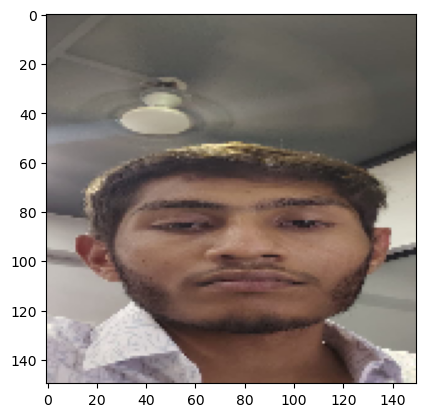

In [20]:
plt.imshow(image)

In [21]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [22]:
predict

array([[0.9850728]], dtype=float32)

In [23]:
test_loss, test_accuracy = model.evaluate(data_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 326ms/step - accuracy: 0.9990 - loss: 0.0718
Test Accuracy: 99.90%


In [24]:
y_true = []
y_pred = []

data_test_processed = data_test.map(process)

for images, labels in data_test_processed:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    binary_preds = (preds > 0.5).astype(int).flatten()
    y_pred.extend(binary_preds)

accuracy = accuracy_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)

print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("Confusion Matrix:\n", conf_matrix)

Accuracy Score: 99.90%
Confusion Matrix:
 [[482   1]
 [  0 509]]
